# pandas数据管理库学习

参考网址: https://pandas.pydata.org/docs/user_guide/groupby.html

## 分组功能 Group By

分组操作主要包含以下过程:
- 分割(Splitting):将数据分割成一个个小组
- 操作(Applying):对每个小组使用独立的function
- 组合(Combining):将结果聚合成一个数据结构

其中apply过程主要有以下操作:
- Aggregation 聚合,求和,均值或者计数
- Transformation 对组内数据进行归一化
- Filtration 对组进行删减,如删除数据量较少的组

> 可以使用`sql`的思维来处理
```SQL
SELECT Column1, Column2, mean(Column3), sum(Column4)
FROM SomeTable
GROUP BY Column1, Column2
```

## Splitting

> `groupby`

调用`groupby`得到的是一个 GroupBy object 对象

通过对GroupBy object调用`.groups`可以获得一个字典对象,这个字典对象就是聚合结果

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
user = pd.read_csv("train_preliminary/train_preliminary/user.csv")

> DataFrame支持`非唯一`索引  
> 在载入csv文件时,会自动生成范围索引: `RangeIndex: 900000 entries, 0 to 899999`  
> 可以使用 set_index 设置其中的一列或多列为数据集索引  
> 若是多索引数组,此时的数据集是一个高维数据集

In [16]:
user.info()
# 自动导入了

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 900000 entries, (4, 1) to (3, 2)
Data columns (total 1 columns):
user_id    900000 non-null int64
dtypes: int64(1)
memory usage: 8.6 MB


In [39]:
user = user.set_index(['age','gender'])

In [4]:
user.groupby(level=0).agg(lambda x:x.count())

,user_id
age,
1,35195
2,149271
3,202909
4,150578
5,130667
6,101720
7,66711
8,31967
9,19474


In [5]:
user.groupby(level=1).agg(lambda x:x.count())

,user_id
gender,
1,602610
2,297390


### GroupBy 排序

默认情况下,keys会在组合成最后的数据时会被自动排序,使用参数sort=False即可


In [7]:
user.groupby(level=0,sort=False).agg(lambda x:x.count())

,user_id
age,
4,150578
10,11508
7,66711
5,130667
6,101720
9,19474
8,31967
3,202909
2,149271


### GroupBy 对象属性

- `.groups`获取字典对象,其实这个对象字典只是一个索引文件,如果使用唯一索引,将很好理解
- `.get_group('key')` 获取对应key下的数据

In [22]:
user.groupby(['age','gender']).get_group((1,1))

user_id
age gender         
1   1            44
    1            56
    1           107
    1           176
    1           184
...             ...
    1        899641
    1        899652
    1        899672
    1        899726
    1        899792

[22796 rows x 1 columns]

## Aggregation

对groups对象使用`aggregate()`或者`agg()`

这样的函数还有:
- mean() Compute mean of groups
- sum() Compute sum of group values
- size() Compute group sizes
- count() Compute count of group
- std() Standard deviation of groups
- var() Compute variance of groups
- sem() Standard error of the mean of groups
- describe() Generates descriptive statistics
- first() Compute first of group values
- last() Compute last of group values
- nth() Take nth value, or a subset if n is a list
- min() Compute min of group values
- max() Compute max of group values
- lambda 算子 支持复杂逻辑

> 除lambda以外上面的函数都使用了cython优化,所以...

In [23]:
user.groupby(['age','gender']).size()

age  gender
1    1          22796
     2          12399
2    1          98248
     2          51023
3    1         134473
     2          68436
4    1         104008
     2          46570
5    1          90691
     2          39976
6    1          69495
     2          32225
7    1          43806
     2          22905
8    1          20167
     2          11800
9    1          11937
     2           7537
10   1           6989
     2           4519
dtype: int64

In [25]:
user.groupby(['age','gender']).count()

user_id
age gender         
1   1         22796
    2         12399
2   1         98248
    2         51023
3   1        134473
    2         68436
4   1        104008
    2         46570
5   1         90691
    2         39976
6   1         69495
    2         32225
7   1         43806
    2         22905
8   1         20167
    2         11800
9   1         11937
    2          7537
10  1          6989
    2          4519

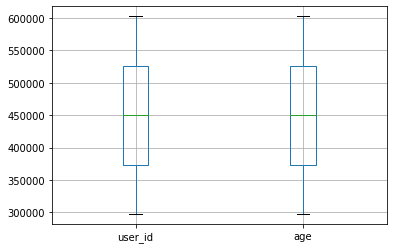

In [7]:
%matplotlib inline
allcount = user.shape[0]

user.groupby(['age','gender']) \
    .agg(lambda x : float(x.count()/allcount)*100 ) \
    .rename(columns={'user_id':'user_count'}).plot()

## Transformation

transfrom 函数必须满足的:
- 返回结果的列可以与原始数据集一致
- Operate column-by-column on the group chunk. 
- (懒求值),在里面使用一些函数时,需要将inplace参数设置为0以减少错误

> Transformation的本质是对原始数据进行聚合,获取组内性质,然后根据这些性质对数据进行修改  
> 所以最后的结果可能与原始一致,这种类型的操作大部分会使用在时间序列类型的数据中

transfrom的另一类应用就是对 NaN 的修改和填补
> 有一组属性确定且没有丢失  
> 按这组数据进行分组,然后根据组内信息对其他存在丢失的属性进行填补

## 窗口和重采样操作[略]

下列函数可以作为groupby的功能:
- resample() 
- expanding() 
- rolling() 

> 暂时还不知道这三个项目干嘛用的

## Filtration

> `filter`函数用于过滤groups





In [68]:
user.groupby(['age','gender']).filter(lambda x:x.count() > 120000)

user_id
age gender         
3   1            17
    1            19
    1            33
    1            39
    1            60
...             ...
    1        899937
    1        899952
    1        899989
    1        899991
    1        899999

[134473 rows x 1 columns]

## Apply 函数

这个例子有点苦

```
# could also just call .describe()
In [149]: grouped['C'].apply(lambda x: x.describe())
Out[149]: 
A         
bar  count    3.000000
     mean     0.130980
     std      0.181231
     min     -0.077118
     25%      0.069390
                ...   
foo  min     -1.143704
     25%     -0.862495
     50%     -0.575247
     75%     -0.408530
     max      1.193555
Name: C, Length: 16, dtype: float64
```

In [ ]:
def f(group):
    return pd.DataFrame({'user_count':group})

user.groupby(['age','gender'])['user_id'].apply(f)